In [4]:
import os
import pandas as pd
import ast

df2=pd.read_csv('../dataset/dataset_polymorphs_icsd.csv')

In [5]:
import re

def parse_ox_states(formula):
    # example: "Si4+3 O2-6"
    parts = formula.split()
    ox = {}
    for p in parts:
        match = re.match(r"([A-Za-z]+)([-+]?\d+)([-+]?)", p)
        if match:
            elem = match.group(1)
            ox_state = match.group(2) + match.group(3)  # e.g., "4+"
            ox[elem] = ox_state
    return ox
df2["ox_state"] = df2["full_formula"].apply(parse_ox_states)


In [ ]:
df3=df2[df2['reduced_formula']=='SiO2']
# df3['ox_state'].value_counts()# 

In [7]:
# Remove formulas with only 1 structure (not polymorphs)
formula_counts = df2['reduced_formula'].value_counts()
polymorphic_formulas = formula_counts[formula_counts > 1].index
df2 = df2[df2['reduced_formula'].isin(polymorphic_formulas)]

print(f"Formulas with >1 structure: {len(polymorphic_formulas)}")
print(f"Total structures remaining: {len(df2)}")


Formulas with >1 structure: 7130
Total structures remaining: 19581


In [8]:
from collections import defaultdict

# Group by reduced_formula to find polymorphs and their oxidation states
formula_data = defaultdict(lambda: {'count': 0, 'ox_states': set()})

for i in range(len(df2)):
    rd_formula = df2["reduced_formula"].iloc[i]
    ox_set = df2["ox_state"].iloc[i]
    
    # Increment polymorph count
    formula_data[rd_formula]['count'] += 1
    
    # Add oxidation state combination if it exists
    try:
        if ox_set and ox_set != set():
            os_string = ", ".join(sorted(ox_set))  # Normalize to consistent string
            formula_data[rd_formula]['ox_states'].add(os_string)
    except:
        pass

# Filter to only formulas with more than one polymorph
polymorph_formulas = {k: v for k, v in formula_data.items() if v['count'] > 1}

# Create data for plotting
num_polymorphs = [v['count'] for v in polymorph_formulas.values()]
num_ox_state_combinations = [len(v['ox_states']) for v in polymorph_formulas.values()]

print(f"Total formulas: {len(formula_data)}")
print(f"Formulas with >1 polymorph: {len(polymorph_formulas)}")
print(f"Polymorph count range: {min(num_polymorphs)} - {max(num_polymorphs)}")
print(f"Oxidation state combination range: {min(num_ox_state_combinations) if num_ox_state_combinations else 0} - {max(num_ox_state_combinations) if num_ox_state_combinations else 0}")


Total formulas: 7130
Formulas with >1 polymorph: 7130
Polymorph count range: 2 - 196
Oxidation state combination range: 1 - 6


In [9]:
# Statistics by number of oxidation state combinations
ox_state_stats = defaultdict(int)
for v in polymorph_formulas.values():
    num_ox_states = len(v['ox_states'])
    ox_state_stats[num_ox_states] += 1

print("\nDistribution by oxidation state combinations:")
for ox_count in sorted(ox_state_stats.keys()):
    print(f"  {ox_count} oxidation state(s): {ox_state_stats[ox_count]} formulas")
# Show formulas with 3 oxidation state combinations
formulas_with_3_ox = {k: v for k, v in polymorph_formulas.items() if len(v['ox_states']) == 3}

print(f"Formulas with 3 oxidation state combinations: {len(formulas_with_3_ox)}\n")
for formula, data in sorted(formulas_with_3_ox.items()):
    print(f"{formula}:")
    print(f"  Polymorphs: {data['count']}")
    print(f"  Oxidation states:")
    for ox_state in sorted(data['ox_states']):
        print(f"    - {ox_state}")
    print()



Distribution by oxidation state combinations:
  1 oxidation state(s): 7125 formulas
  2 oxidation state(s): 4 formulas
  6 oxidation state(s): 1 formulas
Formulas with 3 oxidation state combinations: 0



C:\Users\moons\AppData\Local\Temp\ipykernel_27560\188197153.py:91: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=3.0)


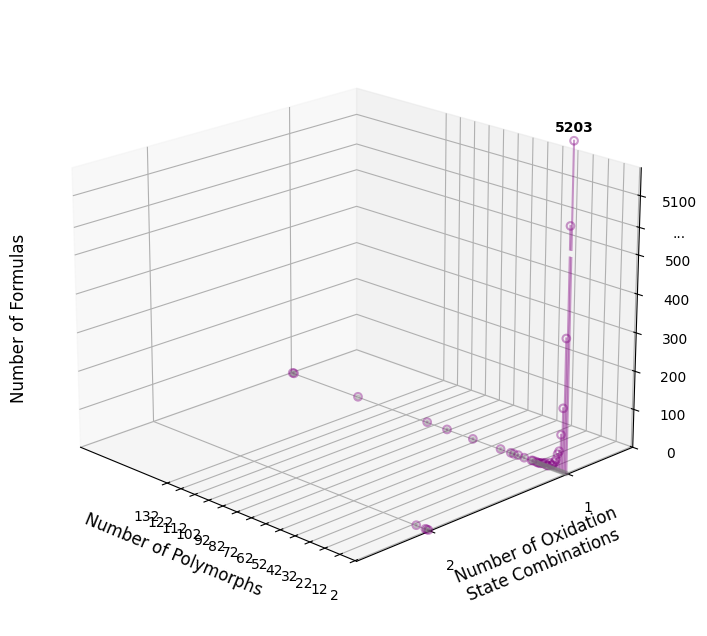


Data summary:
Total formulas with >1 polymorph (ox_state <= 3): 38
Unique (polymorphs, oxidation states) combinations: 38

Most common combinations:
  2 polymorphs, 1 oxidation state(s): 5203 formulas
  3 polymorphs, 1 oxidation state(s): 1106 formulas
  4 polymorphs, 1 oxidation state(s): 345 formulas
  5 polymorphs, 1 oxidation state(s): 165 formulas
  6 polymorphs, 1 oxidation state(s): 95 formulas


In [11]:
# Alternative visualization: 3D column chart
from collections import Counter
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
# Count frequency of each (polymorph, oxidation state) combination
point_counts = Counter(zip(num_polymorphs, num_ox_state_combinations))

# Filter to only combinations where oxidation state count <= 3
filtered_points = [(x, y, count) for (x, y), count in point_counts.items() if y <= 3]

x_vals = [x for x, y, count in filtered_points]
y_vals = [y for x, y, count in filtered_points]
z_vals = [count for x, y, count in filtered_points]

# Create 3D plot
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# Find top value for annotation
if filtered_points:
    top_1 = max(filtered_points, key=lambda t: t[2])
else:
    top_1 = None

for x, y, z in zip(x_vals, y_vals, z_vals):
    if z > 550:  # Only apply scale break for high outliers
        # Draw solid line to 550
        ax.plot([x, x], [y, y], [0, 550], color='purple', linewidth=1.5, alpha=0.4)
        # Map z from 550-2500 to 600-700 range
        scaled_z = 600 + (z - 550) / (2500 - 550) * 100
        # Draw solid line from break to scaled position (connected)
        ax.plot([x, x], [y, y], [570, scaled_z], color='purple', linewidth=1.5, alpha=0.4)
        ax.scatter([x], [y], [scaled_z], facecolors='none', edgecolors='purple', s=30, marker='o', linewidths=1.5, alpha=0.4)
    else:
        ax.plot([x, x], [y, y], [0, z], color='purple', linewidth=1.5, alpha=0.4)
        ax.scatter([x], [y], [z], facecolors='none', edgecolors='purple', s=30, marker='o', linewidths=1.5, alpha=0.4)

# Annotate the top most ball
if top_1:
    x, y, z = top_1
    if z > 550:
        scaled_z = 600 + (z - 550) / (2500 - 550) * 100
        ax.text(x, y, scaled_z + 15, f'{z}', fontsize=10, ha='center', va='bottom', weight='bold', color='black')
    else:
        ax.text(x, y, z + 10, f'{z}', fontsize=10, ha='center', va='bottom', weight='bold', color='black')

# Add base markers to show grid alignment
ax.scatter(x_vals, y_vals, [0]*len(x_vals), color='gray', s=10, alpha=0.3, marker='o')

# Labels and title
ax.set_xlabel('Number of Polymorphs', fontsize=12, labelpad=10)
ax.set_ylabel('Number of Oxidation\nState Combinations', fontsize=12, labelpad=10)
# Use text instead of set_zlabel for better positioning
ax.text2D(-0.02, 0.5, 'Number of Formulas', transform=ax.transAxes, 
          fontsize=12, rotation=90, va='center', ha='right')

# Set integer ticks and limits
ax.set_xticks([2, 12, 22, 32, 42, 52, 62, 72, 82, 92, 102, 112, 122, 132])
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True, prune=None))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}'))

# Custom z-axis ticks: 0, 100, 200, 300, 400, 500, ..., then high values
z_max = max(z_vals) if z_vals else 0
if z_max > 550:
    # Normal scale 0-550, then break, then high value
    z_tick_locs = [0, 100, 200, 300, 400, 500, 570, 650]
    z_tick_labels = ['0', '100', '200', '300', '400', '500', '...', '5100']
    ax.set_zticks(z_tick_locs)
    ax.set_zticklabels(z_tick_labels)
    ax.set_zlim(0, 720)
else:
    ax.zaxis.set_major_locator(plt.MultipleLocator(100))
    ax.set_zlim(0, z_max*1.1 if z_max > 0 else 1)

# Set appropriate limits to show all data
if x_vals:
    ax.set_xlim(min(x_vals)-1, max(x_vals)+1)
if y_vals:
    ax.set_ylim(min(y_vals)-0.5, max(y_vals)+0.5)

# Adjust viewing angle for better perspective - higher azimuth to see z-label
ax.view_init(elev=20, azim=135)

# Tick label sizes
ax.tick_params(labelsize=10, pad=8)

# Add grid
ax.grid(True, alpha=0.3)

plt.tight_layout(pad=3.0)
# plt.savefig("overleaf_icsd_os.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\nData summary:")
print(f"Total formulas with >1 polymorph (ox_state <= 3): {len(x_vals)}")
print(f"Unique (polymorphs, oxidation states) combinations: {len(filtered_points)}")
print(f"\nMost common combinations:")
for x, y, count in sorted(filtered_points, key=lambda t: t[2], reverse=True)[:5]:
    print(f"  {x} polymorphs, {y} oxidation state(s): {count} formulas")
